# Pneumonia Detection via EfficientNet

## Imports & Drive Mount

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import collections

import tensorflow as tf
from tensorflow import keras
from keras import layers
import sklearn.metrics as sk_metrics

import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


## Configuration

In [2]:
DATASET_PATH = "/content/drive/MyDrive/computer vision course/projects/Chest X-Ray Images (Pneumonia)/Dataset"
IMG_SIZE     = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

## Dataset Loading & Splitting

In [3]:
Train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode="rgb"
)

class_names = Train_dataset.class_names
print("Classes:", class_names)            # ['NORMAL', 'PNEUMONIA']

val_test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    color_mode="rgb"
)

val_batches       = int(len(val_test_dataset) * (3/4))
validation_dataset = val_test_dataset.take(val_batches)
Testing_dataset     = val_test_dataset.skip(val_batches)

AUTOTUNE = tf.data.AUTOTUNE
Train_dataset      = Train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
Testing_dataset    = Testing_dataset.prefetch(buffer_size=AUTOTUNE)

print(f"\nTrain batches:      {len(Train_dataset)}")
print(f"Validation batches: {len(validation_dataset)}")
print(f"Test batches:       {len(Testing_dataset)}")

Found 5856 files belonging to 2 classes.
Using 4685 files for training.
Classes: ['NORMAL', 'PNEUMONIA']
Found 5856 files belonging to 2 classes.
Using 1171 files for validation.

Train batches:      147
Validation batches: 27
Test batches:       10


## Handle Class Imbalance via Class Weights

In [4]:
def get_class_weights(dataset):
    class_counts = collections.defaultdict(int)
    for _, labels in dataset.unbatch():
        class_counts[int(labels.numpy())] += 1
    total = sum(class_counts.values())
    n_cls = len(class_counts)
    weights = {cls: total / (n_cls * cnt) for cls, cnt in class_counts.items()}
    return weights

class_weights = get_class_weights(Train_dataset)
print("Class Names   :", class_names)
print("Class Counts  :", dict(collections.Counter(
    int(l) for _, labels in Train_dataset.unbatch() for l in [labels])))
print("Class Weights :", class_weights)

Class Names   : ['NORMAL', 'PNEUMONIA']
Class Counts  : {1: 3385, 0: 1300}
Class Weights : {1: 0.6920236336779911, 0: 1.801923076923077}


## Data Augmentation

In [5]:
# للـ Chest X-Ray: لا vertical flip، rotation صغيرة، brightness مهم
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),       # horizontal فقط — X-rays مش بتتقلب vertical
    layers.RandomRotation(0.05),           # ± 5% فقط — مش أكتر في الطبي
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),          # مهم لـ X-rays لأن exposure بيختلف
    layers.RandomContrast(0.15),
], name="data_augmentation")

## Model Architecture

In [6]:
base_model = keras.applications.EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
base_model.trainable = False


# ✅ Functional API
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)
x = keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)  # Binary: 0=Normal, 1=Pneumonia

model = keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,382,884 (16.72 MB)

 Trainable params: 330,753 (1.26 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

## Model Training

### Model Training Phase 1 : Feature Extraction (Base Frozen)

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

callbacks_phase1 = [
    keras.callbacks.EarlyStopping(
        patience=5,
        restore_best_weights=True,
        monitor='val_auc',
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        patience=3,
        factor=0.3
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_phase1.keras",
        save_best_only=True,
        monitor='val_auc',
        mode='max'
    )
]

history1 = model.fit(
    Train_dataset,
    validation_data=validation_dataset,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks_phase1
)

Epoch 1/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 151s 913ms/step - accuracy: 0.8515 - auc: 0.9273 - loss: 0.3810 - precision: 0.9354 - recall: 0.8513 - val_accuracy: 0.9306 - val_auc: 0.9820 - val_loss: 0.1946 - val_precision: 0.9730 - val_recall: 0.9345 - learning_rate: 0.0010
Epoch 2/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 62s 425ms/step - accuracy: 0.9238 - auc: 0.9760 - loss: 0.2088 - precision: 0.9764 - recall: 0.9159 - val_accuracy: 0.8993 - val_auc: 0.9808 - val_loss: 0.1984 - val_precision: 0.9735 - val_recall: 0.8921 - learning_rate: 0.0010
Epoch 3/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 55s 376ms/step - accuracy: 0.9208 - auc: 0.9779 - loss: 0.1978 - precision: 0.9749 - recall: 0.9122 - val_accuracy: 0.9016 - val_auc: 0.9836 - val_loss: 0.2119 - val_precision: 0.9865 - val_recall: 0.8837 - learning_rate: 0.0010
Epoch 4/20
147/147 ━━━━━━━━━━━━━━━━━━━━ 53s 361ms/step - accuracy: 0.9211 - auc: 0.9807 - loss: 0.1886 - precision: 0.9749 - recall: 0.9136 - val_accuracy: 0.9178 - val_auc: 0.9853 - val_loss:

### Model Training Phase 2 : Fine Tuning (unfreeze Last Layers)

In [8]:
# ✅ Unfreeze آخر 20 layer
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

# ✅ smaller LR for fine-tuning
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc"),
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall")
    ]
)

callbacks_phase2 = [
    keras.callbacks.EarlyStopping(
        patience=7,
        restore_best_weights=True,
        monitor='val_auc',
        mode='max'
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        patience=4,
        factor=0.5
    ),
    keras.callbacks.ModelCheckpoint(
        "best_model_final.keras",
        save_best_only=True,
        monitor='val_auc',
        mode='max'
    )
]

history2 = model.fit(
    Train_dataset,
    validation_data=validation_dataset,
    epochs=30,
    class_weight=class_weights,
    callbacks=callbacks_phase2
)

Epoch 1/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 69s 378ms/step - accuracy: 0.9122 - auc: 0.9641 - loss: 0.2573 - precision: 0.9531 - recall: 0.9224 - val_accuracy: 0.9259 - val_auc: 0.9830 - val_loss: 0.1712 - val_precision: 0.9776 - val_recall: 0.9244 - learning_rate: 1.0000e-05
Epoch 2/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 51s 350ms/step - accuracy: 0.9310 - auc: 0.9798 - loss: 0.1844 - precision: 0.9728 - recall: 0.9294 - val_accuracy: 0.9144 - val_auc: 0.9803 - val_loss: 0.1949 - val_precision: 0.9792 - val_recall: 0.9094 - learning_rate: 1.0000e-05
Epoch 3/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 50s 340ms/step - accuracy: 0.9314 - auc: 0.9794 - loss: 0.1821 - precision: 0.9746 - recall: 0.9281 - val_accuracy: 0.9225 - val_auc: 0.9820 - val_loss: 0.1845 - val_precision: 0.9791 - val_recall: 0.9184 - learning_rate: 1.0000e-05
Epoch 4/30
147/147 ━━━━━━━━━━━━━━━━━━━━ 52s 356ms/step - accuracy: 0.9305 - auc: 0.9821 - loss: 0.1711 - precision: 0.9737 - recall: 0.9281 - val_accuracy: 0.9225 - val_auc: 0.9857 

### Training Results Visualization

In [9]:
def plot_history(history, title):
    fig = make_subplots(rows=1, cols=3, subplot_titles=('Loss', 'AUC', 'Accuracy'))
    for col, (metric, val_metric) in enumerate([('loss','val_loss'),('auc','val_auc'), ('accuracy','val_accuracy')], 1):
        fig.add_trace(go.Scatter(y=history.history[metric],      name='Train', marker_color='blue',  mode='lines'), row=1, col=col)
        fig.add_trace(go.Scatter(y=history.history[val_metric],  name='Val',   marker_color='red',   mode='lines'), row=1, col=col)
    fig.update_layout(height=530, width=1350, title_text=title)
    fig.show()

plot_history(history1, "Phase 1: Feature Extraction")
plot_history(history2, "Phase 2: Fine-Tuning")

## Model Evaluation

In [10]:
all_preds  = []
all_labels = []
all_probs  = []

for images, labels in Testing_dataset:
    probs = model.predict(images, verbose=0).flatten()
    preds = (probs > 0.5).astype(int)
    all_probs.extend(probs)
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

print("Classification Report:\n")
print(sk_metrics.classification_report(all_labels, all_preds, target_names=class_names))

Classification Report:

              precision    recall  f1-score   support

      NORMAL       0.86      0.94      0.90        78
   PNEUMONIA       0.98      0.95      0.96       229

    accuracy                           0.94       307
   macro avg       0.92      0.94      0.93       307
weighted avg       0.95      0.94      0.95       307



### Confusion Matrix

In [11]:
cm = sk_metrics.confusion_matrix(all_labels, all_preds)

fig = px.imshow(
    cm,
    labels=dict(x="Predicted", y="Actual", color="Count"),
    x=class_names,
    y=class_names,
    text_auto=True,
    color_continuous_scale='Blues',
    title="Confusion Matrix"
)
fig.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (Normal → Normal):       {tn}")
print(f"False Positives (Normal → Pneumonia):    {fp}  ← Not a tough problem" )
print(f"False Negatives (Pneumonia → Normal):    {fn}  ← most dangerious !")
print(f"True Positives  (Pneumonia → Pneumonia): {tp}")

True Negatives  (Normal → Normal):       73
False Positives (Normal → Pneumonia):    5  ← Not a tough problem
False Negatives (Pneumonia → Normal):    12  ← most dangerious !
True Positives  (Pneumonia → Pneumonia): 217


### Threshold Tuning ( Threshold optimizing for better recall )

In [1]:
thresholds = np.arange(0.2, 0.8, 0.05)
results = []
for t in thresholds:
    preds_t = (all_probs > t).astype(int)
    recall    = sk_metrics.recall_score(all_labels, preds_t)
    precision = sk_metrics.precision_score(all_labels, preds_t)
    f1        = sk_metrics.f1_score(all_labels, preds_t)
    results.append((t, recall, precision, f1))

df_thresh = pd.DataFrame(results, columns=['Threshold', 'Recall', 'Precision', 'F1'])

fig = go.Figure()
fig.add_trace(go.Scatter(x=df_thresh.Threshold, y=df_thresh.Recall,    name='Recall',    mode='lines+markers'))
fig.add_trace(go.Scatter(x=df_thresh.Threshold, y=df_thresh.Precision, name='Precision', mode='lines+markers'))
fig.add_trace(go.Scatter(x=df_thresh.Threshold, y=df_thresh.F1,        name='F1',        mode='lines+markers'))
fig.add_vline(x=0.5, line_dash='dash', line_color='red', annotation_text='Default 0.5')
fig.update_layout(title='Threshold vs Metrics', xaxis_title='Threshold', height=400)
fig.show()

best_f1_row     = df_thresh.loc[df_thresh.F1.idxmax()]
best_recall_row = df_thresh.loc[df_thresh.Recall.idxmax()]
print(f"\nBest F1 threshold: {best_f1_row.Threshold:.2f}")
print(f"\nBest recall threshold: {best_recall_row.Threshold:.2f}\n")
display(df_thresh)

NameError: name 'np' is not defined

### Sample Predictions

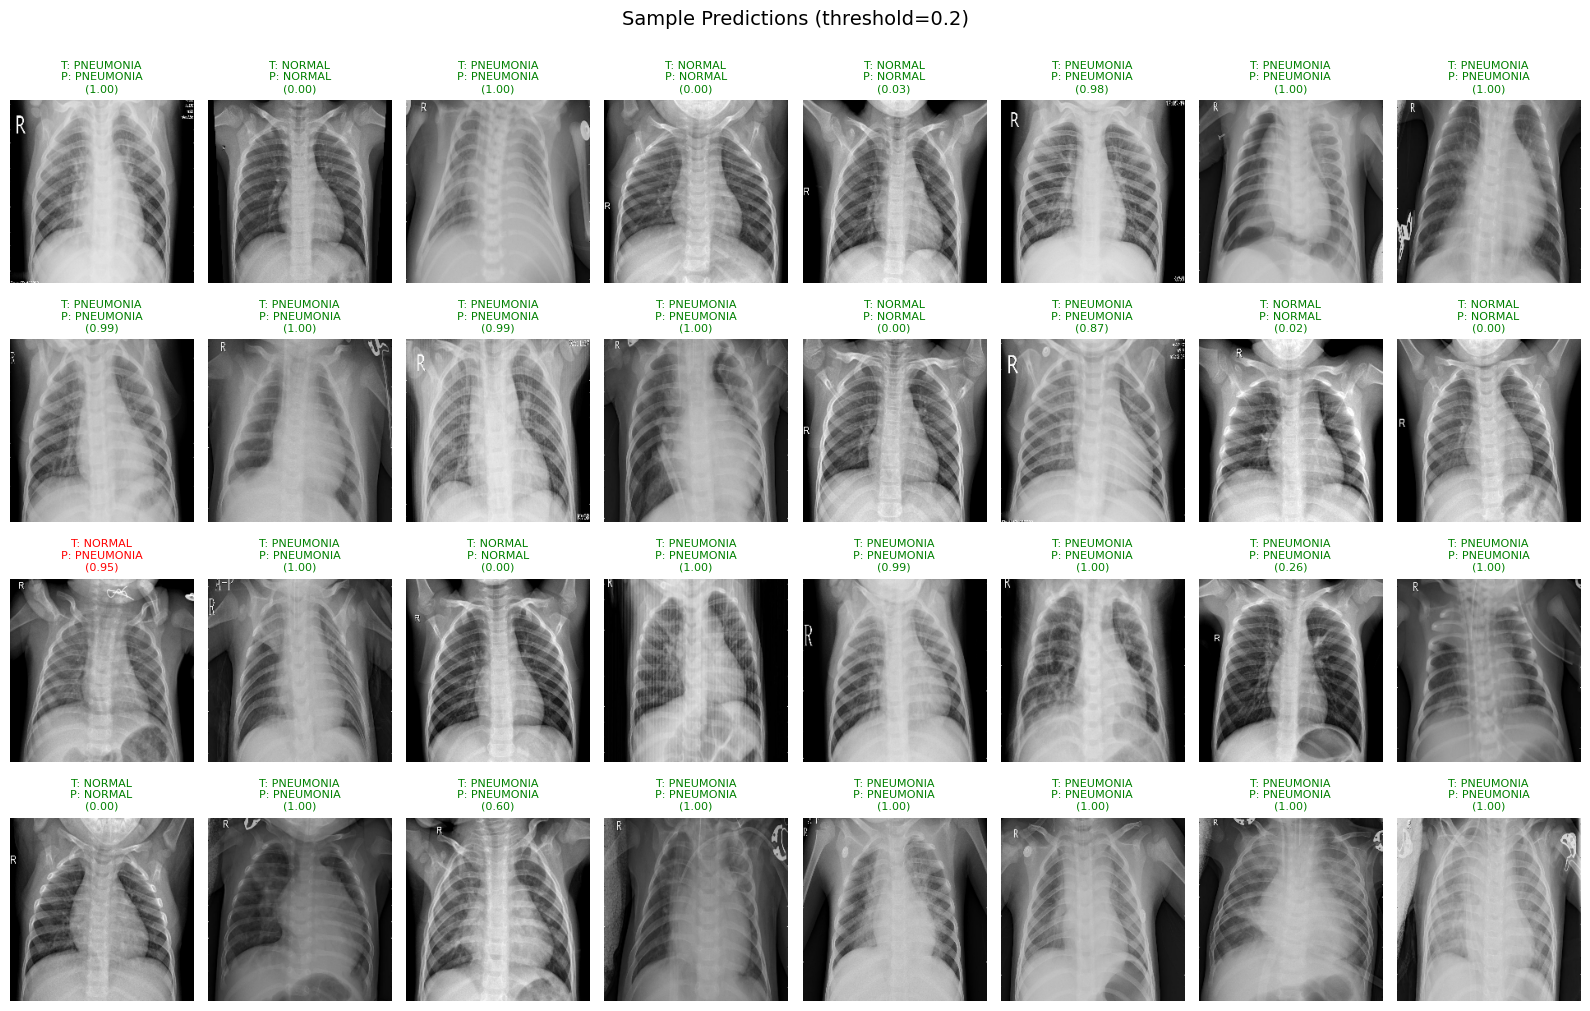

In [13]:
THRESHOLD = 0.2  # determined from the threshold tuning results ( best for recall - to capture the maximum number of pneumonia cases )

plt.figure(figsize=(16, 10.5))
for images, labels in Testing_dataset.skip(2).take(1):
    batch_images = images.numpy()
    true_labels  = labels.numpy()
    break

# ✅ prediction using the flatten() , and threshold
probs_batch = model.predict(images, verbose=0).flatten()
pred_labels = (probs_batch > THRESHOLD).astype(int)

for i in range(min(len(batch_images), 32)):
    plt.subplot(4, 8, i + 1)
    img = batch_images[i]
    img = (img - img.min()) / (img.max() - img.min())
    plt.imshow((img * 255).astype('uint8'))

    true_name = class_names[true_labels[i]]
    pred_name = class_names[pred_labels[i]]
    prob      = probs_batch[i]

    color = 'green' if true_labels[i] == pred_labels[i] else 'red'
    plt.title(f"T: {true_name}\nP: {pred_name}\n({prob:.2f})", fontsize=8, color=color)
    plt.axis('off')

plt.suptitle(f"Sample Predictions (threshold={THRESHOLD})\n", fontsize=14)
plt.tight_layout()
plt.show()

### ROC Curve

In [14]:
fpr, tpr, _ = sk_metrics.roc_curve(all_labels, all_probs)
auc_score   = sk_metrics.roc_auc_score(all_labels, all_probs)

fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC (AUC={auc_score:.3f})', fill='tozeroy'))
fig.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', line=dict(dash='dash', color='gray'), name='Random'))
fig.update_layout(title='ROC Curve', xaxis_title='False Positive Rate', yaxis_title='True Positive Rate', height=450)
fig.show()